In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


In [43]:

df = pd.read_csv("winequality-red.csv")

print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [44]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (1599, 12)

Columns:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')


In [45]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [46]:
print(df["quality"].value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [47]:
df["quality_label"] = (df["quality"] >= 7).astype(int)

print(df[["quality", "quality_label"]].head(10))

   quality  quality_label
0        5              0
1        5              0
2        5              0
3        6              0
4        5              0
5        5              0
6        5              0
7        7              1
8        7              1
9        5              0


In [48]:
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1599, 11)
y shape: (1599,)


In [49]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1279, 11)
Testing data: (320, 11)


In [50]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [51]:

svc = SVC(kernel="rbf", random_state=42)

svc.fit(X_train_scaled, y_train)

y_pred_svc = svc.predict(X_test_scaled)


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)

print("SVC Results")
print("----------------")
print("Accuracy :", accuracy_svc)
print("Precision:", precision_svc)
print("Recall   :", recall_svc)
print("F1 Score :", f1_svc)

SVC Results
----------------
Accuracy : 0.9
Precision: 0.7619047619047619
Recall   : 0.37209302325581395
F1 Score : 0.5


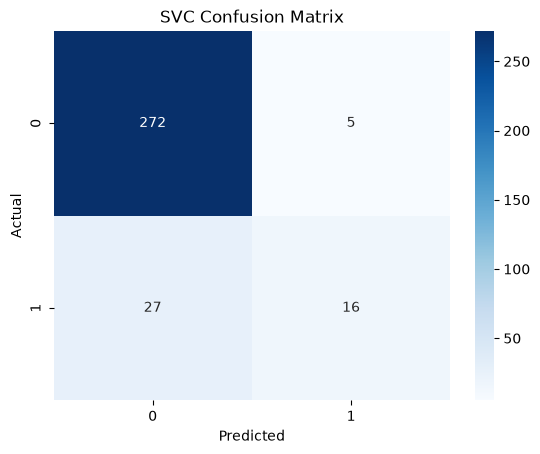

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svc = confusion_matrix(y_test, y_pred_svc)

sns.heatmap(cm_svc, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVC Confusion Matrix")

plt.show()

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [55]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("----------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Results
----------------------
Accuracy : 0.94375
Precision: 0.9310344827586207
Recall   : 0.627906976744186
F1 Score : 0.75


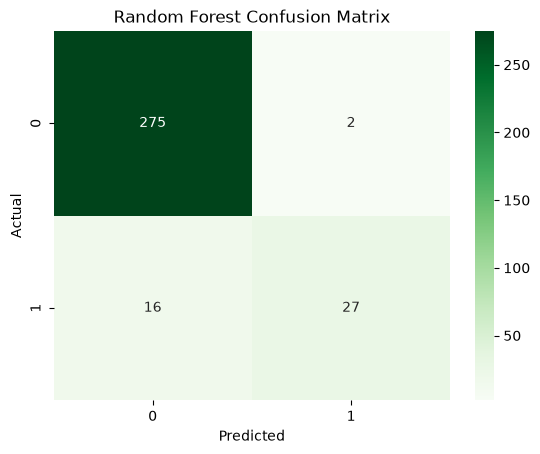

In [56]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [58]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Results
---------------------
Accuracy : 0.9
Precision: 0.6170212765957447
Recall   : 0.6744186046511628
F1 Score : 0.6444444444444445


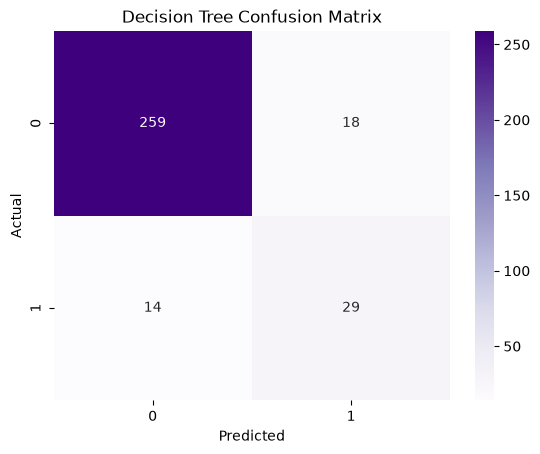

In [59]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Purples")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

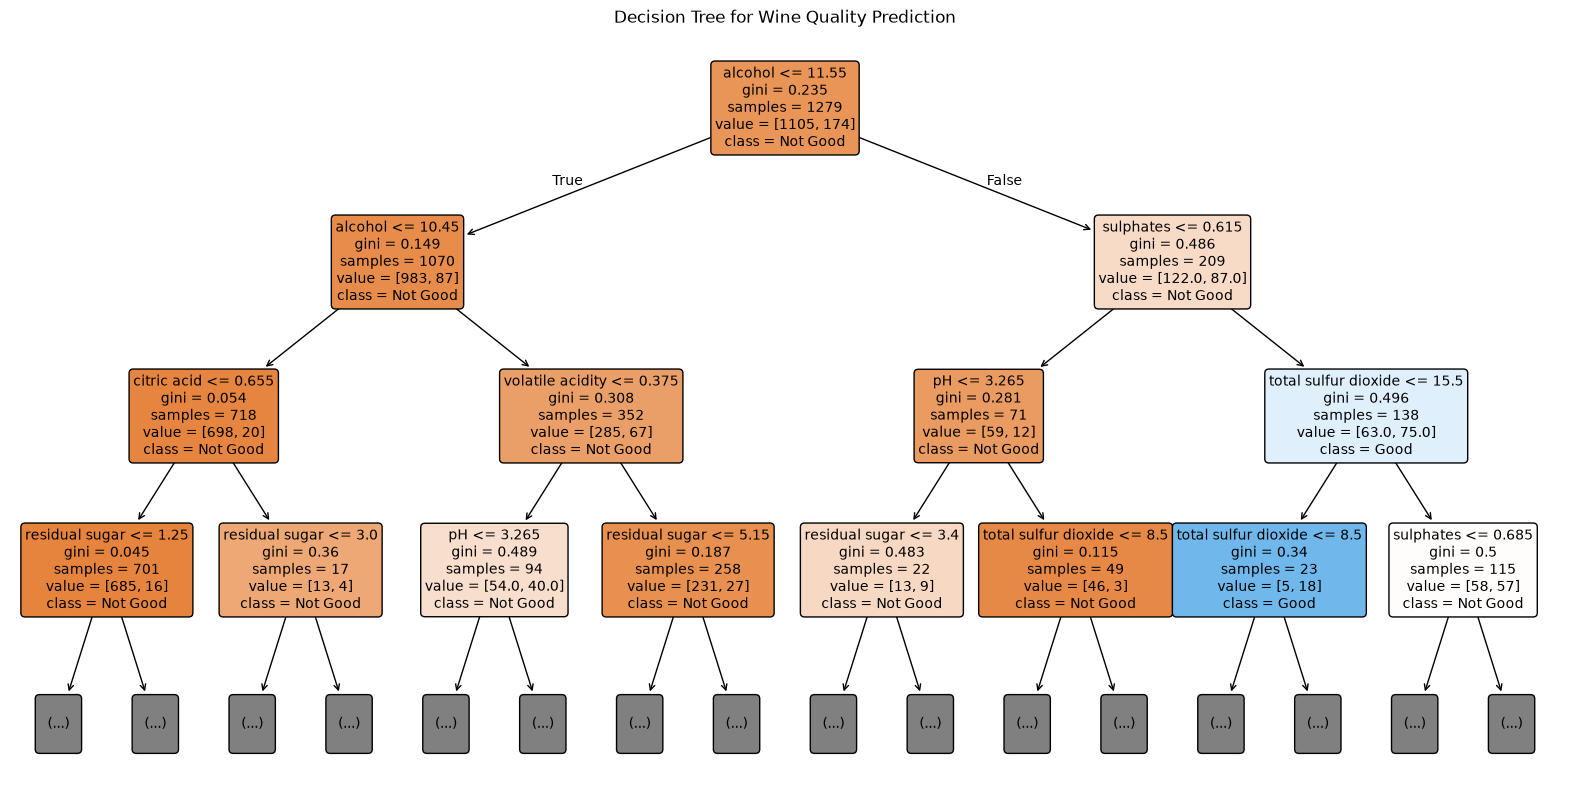

In [60]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Not Good", "Good"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title("Decision Tree for Wine Quality Prediction")
plt.show()

In [61]:
comparison = pd.DataFrame({
    "Algorithm": ["SVC", "Random Forest", "Decision Tree"],
    "Accuracy": [accuracy_svc, accuracy_rf, accuracy_dt],
    "Precision": [precision_svc, precision_rf, precision_dt],
    "Recall": [recall_svc, recall_rf, recall_dt],
    "F1 Score": [f1_svc, f1_rf, f1_dt]
})

print(comparison)

       Algorithm  Accuracy  Precision    Recall  F1 Score
0            SVC   0.90000   0.761905  0.372093  0.500000
1  Random Forest   0.94375   0.931034  0.627907  0.750000
2  Decision Tree   0.90000   0.617021  0.674419  0.644444


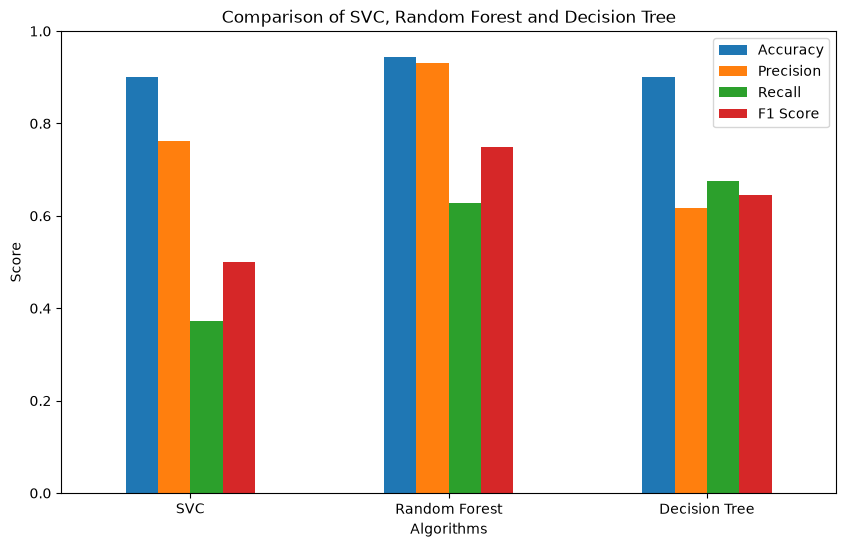

In [62]:
comparison.set_index("Algorithm").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of SVC, Random Forest and Decision Tree")
plt.xlabel("Algorithms")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()